<a href="https://colab.research.google.com/github/AngeloSorte/MNIST-Fashion-Image-Classification-with-Neural-Network/blob/angelosorte.github.io/MNIST_Fashion_Image_Classification_with_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)


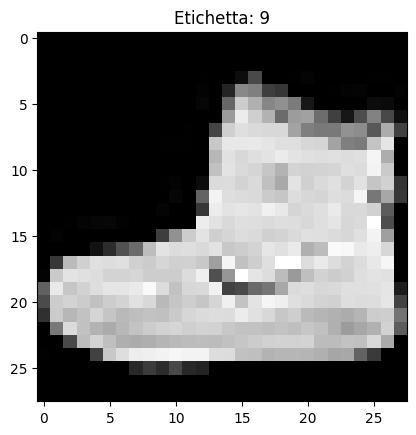

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7861 - loss: 0.6147 - val_accuracy: 0.8432 - val_loss: 0.4284
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8630 - loss: 0.3712 - val_accuracy: 0.8652 - val_loss: 0.3724
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8779 - loss: 0.3361 - val_accuracy: 0.8683 - val_loss: 0.3720
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8893 - loss: 0.3058 - val_accuracy: 0.8747 - val_loss: 0.3554
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8903 - loss: 0.2980 - val_accuracy: 0.8617 - val_loss: 0.3805
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8961 - loss: 0.2776 - val_accuracy: 0.8718 - val_loss: 0.3493
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8994 - loss: 0.2631 - val_accuracy: 0.8805 - val_loss: 0.3334
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9056 - loss: 0.

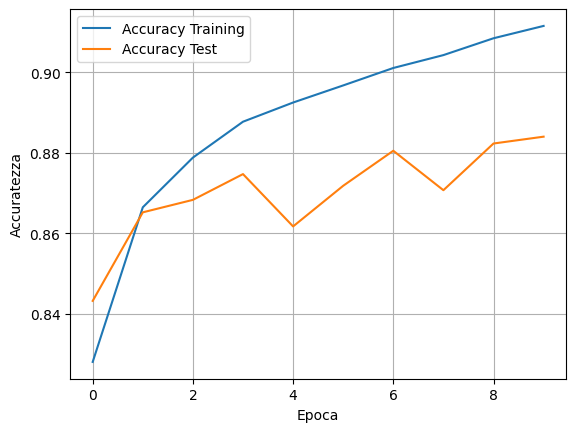

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


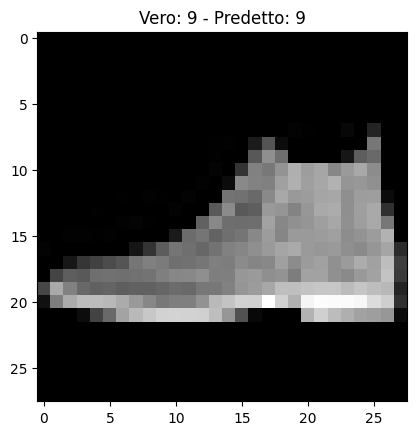

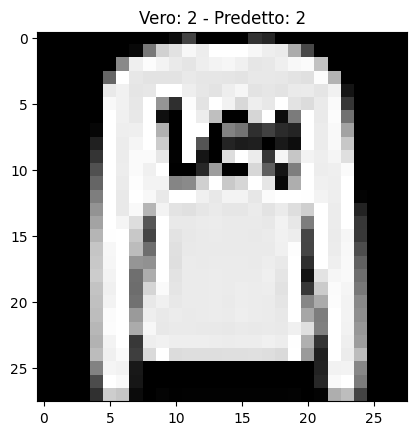

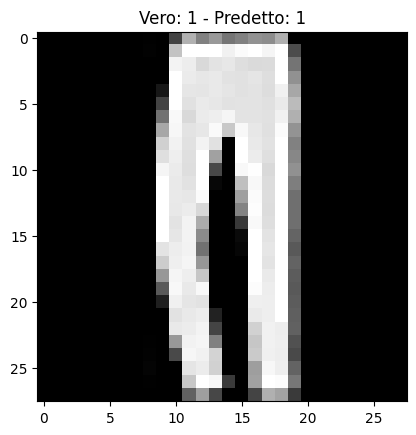

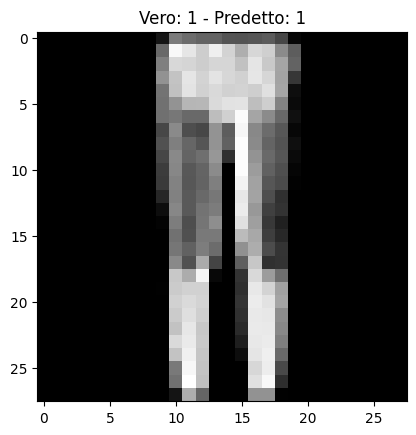

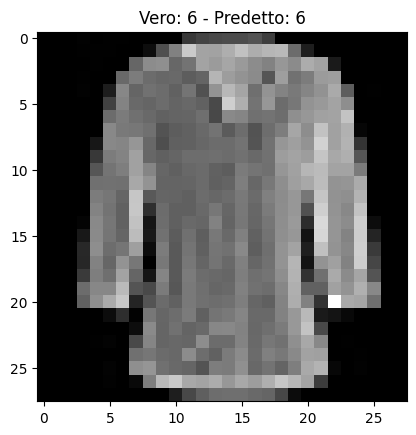

In [ ]:
# 📌 Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 📌 Load the Fashion MNIST dataset included in Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 📌 Normalize pixels (from 0-255 to 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 📌 Check data size
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

# 📌 Show an example image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etichetta: {y_train[0]}")
plt.show()

# 📌 Let's define the sequential model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),           # Transform 28x28 image into 784 vector
    layers.Dense(128, activation='relu'),           # First dense layer with ReLU
    layers.Dense(64, activation='relu'),            # Second dense layer
    layers.Dense(10, activation='softmax')          # Output: 10 classes with probability
])

# 📌 Let's compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 📌 Model training
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# 📌 Evaluation on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n📊 Accuracy sul test set: {test_acc:.4f}")

# 📌 Visualization of accuracy during training
plt.plot(history.history['accuracy'], label='Accuracy Training')
plt.plot(history.history['val_accuracy'], label='Accuracy Test')
plt.xlabel('Epoca')
plt.ylabel('Accuratezza')
plt.legend()
plt.grid(True)
plt.show()

# 📌 Let's view some predictions
predictions = model.predict(x_test)

# Funzione per mostrare immagine e predizione
def show_prediction(index):
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f"Vero: {y_test[index]} - Predetto: {predictions[index].argmax()}")
    plt.show()

# 📌 Show the first 5 predictions
for i in range(5):
    show_prediction(i)
